<a href="https://colab.research.google.com/github/Divyashree-02112006/divya-codeboosters-2026/blob/main/Day%20-%202/mini_project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print(f"pandas version: {pd.__version__}")
print(f"sqlite3 version: {sqlite3.version}")

pandas version: 2.2.2
sqlite3 version: 2.6.0


In [2]:
df=pd.read_csv('student_performance.csv')
print(f"Dataset loaded: {df.shape[0]} students,{df.shape[1]} columns")
print(f"columns:{df.columns.tolist()}")
df.head(3)

Dataset loaded: 30 students,13 columns
columns:['student_id', 'name', 'age', 'gender', 'department', 'semester', 'math_score', 'science_score', 'english_score', 'programming_score', 'attendance_percentage', 'city', 'admission_year']


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023


In [3]:
conn=sqlite3.connect('college.db')
cursor = conn.cursor()

df.to_sql("students", conn, if_exists="replace", index=False)

result = pd.read_sql("SELECT * FROM students LIMIT 5", conn)

print(result)


   student_id          name  age  gender        department  semester  \
0        1001  Aarav Sharma   19    Male  Computer Science         2   
1        1002   Priya Patel   20  Female  Computer Science         2   
2        1003   Rohit Verma   19    Male       Electronics         2   
3        1004   Sneha Reddy   20  Female        Mechanical         2   
4        1005    Arjun Nair   19    Male  Computer Science         2   

   math_score  science_score  english_score  programming_score  \
0          85             78             72                 91   
1          76             82             88                 79   
2          65             74             61                 55   
3          70             80             75                 48   
4          92             88             81                 95   

   attendance_percentage       city  admission_year  
0                     92     Mumbai            2023  
1                     87  Ahmedabad            2023  
2       

In [4]:
def run_query(sql,description="students"):
  if description:
    print(f"{description}")

  result=pd.read_sql_query(sql,conn)
  print(result.to_string(index=False))
  return result

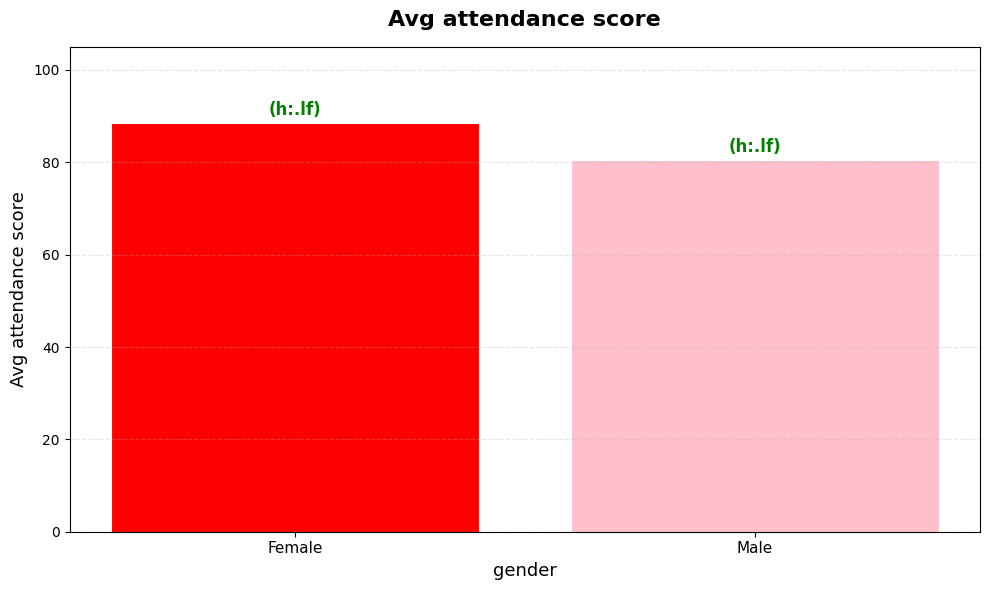

In [12]:
chart1_sql="""SELECT gender,ROUND(AVG(attendance_percentage),2) AS avg_attendance
FROM students
GROUP BY gender
ORDER BY avg_attendance DESC
"""

chart1_data=pd.read_sql_query(chart1_sql,conn)

fig,ax=plt.subplots(figsize=(10,6))

bar_colors=['red','pink','blue','purple']

bars = ax.bar(
    chart1_data['gender'],
    chart1_data['avg_attendance'],
    color= bar_colors,
    edgecolor='white',
    linewidth=0.8
)

for bar in bars:
  h=bar.get_height()
  ax.text(
      bar.get_x() + bar.get_width()/2,
      h+0.8,
      f'(h:.1f)',
      ha='center',va='bottom',
      fontsize=12,fontweight='bold',
      color='green'
  )
ax.set_title('Avg attendance score',fontsize=16,fontweight='bold',pad=15)
ax.set_xlabel('gender',fontsize=13)
ax.set_ylabel('Avg attendance score',fontsize=13)
ax.set_ylim(0,105)
ax.tick_params(axis='x',labelsize=11)
ax.grid(axis='y',alpha=0.3,linestyle='--')

plt.tight_layout()
plt.show()

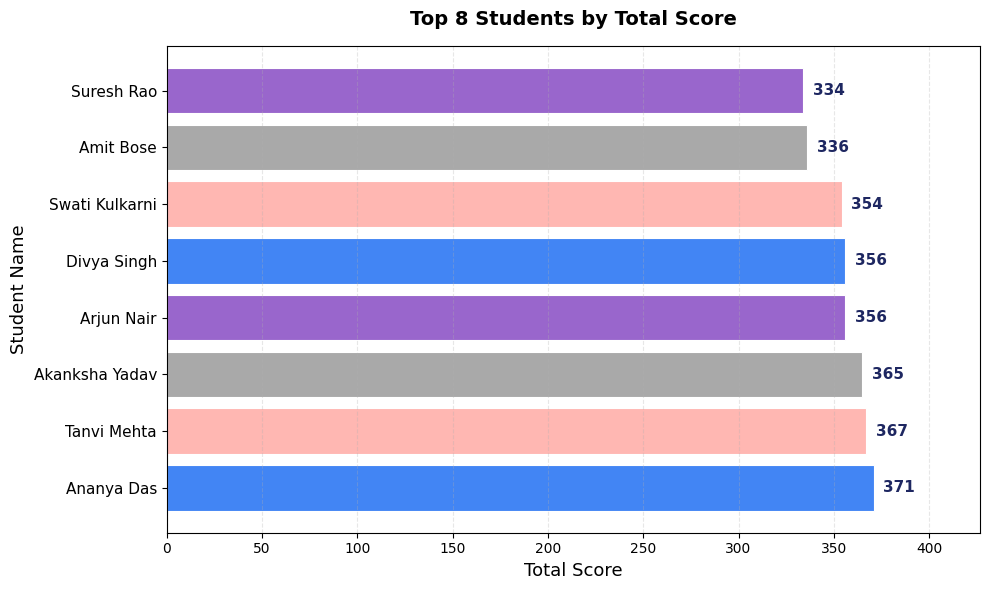

In [16]:
chart2_sql = """
SELECT name, (programming_score + math_score + science_score + english_score) AS total_score
FROM students
ORDER BY total_score DESC
LIMIT 8
"""
chart2_data = pd.read_sql_query(chart2_sql, conn)

fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = ['#4285F4', '#FFB7B2', '#A9A9A9', '#9966CC']

bars = ax.barh(chart2_data['name'],
               chart2_data['total_score'],
               color=bar_colors,
               edgecolor='white',
               linewidth=0.8)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 5,
        bar.get_y() + bar.get_height()/2,
        f'{width:.0f}',
        ha='left', va='center',
        fontsize=11, fontweight='bold',
        color='#1E2761')

ax.set_xlabel('Total Score', fontsize=13)
ax.set_ylabel('Student Name', fontsize=13)
ax.set_title('Top 8 Students by Total Score', fontsize=14, fontweight='bold', pad=15)
max_possible_score = chart2_data['total_score'].max()
ax.set_xlim(0, max_possible_score * 1.15)

ax.tick_params(axis='y', labelsize=11)
ax.grid(axis='x', linestyle='--', alpha=0.3)


plt.tight_layout()
plt.show()

In [19]:
query5 = """
SELECT gender,
AVG(programming_score) as avg_programming
FROM students
WHERE gender ='Female'
GROUP BY gender
"""
result5 = run_query(query5)

students
gender  avg_programming
Female             70.2


In [23]:
query1="""
  SELECT student_id,name,attendance_percentage,department
  FROM students
  WHERE  attendance_percentage > 85
  ORDER BY attendance_percentage DESC
"""
result1=run_query(query1)

students
 student_id           name  attendance_percentage       department
       1010     Ananya Das                     98 Computer Science
       1022    Tanvi Mehta                     97 Computer Science
       1008    Divya Singh                     96 Computer Science
       1004    Sneha Reddy                     95       Mechanical
       1030 Akanksha Yadav                     95 Computer Science
       1018 Swati Kulkarni                     94 Computer Science
       1016   Ritu Agarwal                     93      Electronics
       1001   Aarav Sharma                     92 Computer Science
       1014  Kavya Nambiar                     91       Mechanical
       1025      Amit Bose                     91 Computer Science
       1005     Arjun Nair                     90 Computer Science
       1020   Nisha Kapoor                     89 Computer Science
       1013     Suresh Rao                     88 Computer Science
       1002    Priya Patel                     87 Com

In [26]:
query1="""
  SELECT student_id,name,AVG(attendance_percentage) as avg_att,department
  FROM students
  GROUP BY department HAVING attendance_percentage >85
"""
result1=run_query(query1)

students
 student_id         name   avg_att       department
       1001 Aarav Sharma 90.692308 Computer Science
       1004  Sneha Reddy 83.500000       Mechanical
